# BUS 32120
# Final Project - China Silver Economy: A Screening Analysis of Caregiver Training and Dispatch Opportunity

**Group 7:** Lawrence Li, Jeremy Ye

## AI Usage Disclosure
We used generative AI tools to support brainstorming, code debugging, wording improvement, and project organization. 
All analysis decisions, final interpretations, and submitted work were reviewed and edited by the team.

## 1. Introduction
China's population is aging quickly, which creates growing demand for elder care services. 
At the same time, labor supply in care-related occupations may not be expanding fast enough to fully meet this demand. 
This creates a possible opportunity for businesses focused on caregiver training and dispatch.

The target audience of this analysis is founders or small investors evaluating a caregiver training and staffing business in China. 
Our goal is not to prove that the business will definitely succeed, but to assess whether macro-level trends support deeper business due diligence.

Our main question is: **Does China show enough aging-related demand growth and labor-supply pressure to justify further evaluation of a caregiver training and dispatch startup?**



## 2. Project Roadmap

This notebook proceeds in five steps:

1. Introduce the datasets used in the analysis  
2. Check data quality and clean the data  
3. Build simple features related to elder-care labor pressure  
4. Explore the data with tables and charts  
5. Use two basic models to evaluate whether the patterns are consistent with market pressure

In [29]:
import pandas as pd
import numpy as np
import requests
import sqlite3
import time
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score,
    confusion_matrix, classification_report
)


## 3. Data Sources

This project uses two main datasets.

**Dataset 1: World Bank indicators**
- Country-year macro data for China, Japan, and South Korea
- Main variables include:
  - population ages 65 and above (%)
  - population ages 65 and above (total)
  - nurses and midwives per 1,000 people
  - total population
  - GDP per capita (current US$)

**Dataset 2: China elder-care operations data**
- A small hand-built annual table based on official Chinese statistical releases
- Includes:
  - 65+ population
  - share of population aged 65+
  - number of elder-care institutions
  - number of elder-care beds
  - registered nurses

The World Bank data supports cross-country comparison, while the China-only dataset adds a more business-relevant operational view.

## 4. Load World Bank Data

In [6]:
def fetch_indicator_multi(country_codes, indicator_code, col_name, start_year=1990, end_year=2024, per_page=1000, max_retries=3):

    country_str = ";".join(country_codes)
    url = f"https://api.worldbank.org/v2/country/{country_str}/indicator/{indicator_code}"

    params = {
        "format": "json",
        "date": f"{start_year}:{end_year}",
        "per_page": per_page,
        "page": 1
    }

    for attempt in range(max_retries):
        try:
            response = requests.get(url, params=params, timeout=60)
            response.raise_for_status()
            payload = response.json()

            # Basic safety check
            if not isinstance(payload, list) or len(payload) < 2:
                raise ValueError("Unexpected API response format")

            data = payload[1]

            rows = []
            for item in data:
                rows.append({
                    "iso3": item["countryiso3code"],
                    "country": item["country"]["value"],
                    "year": int(item["date"]),
                    col_name: item["value"]
                })

            df = pd.DataFrame(rows)
            return df

        except Exception as e:
            print(f"Attempt {attempt + 1} failed for {indicator_code}: {e}")
            if attempt < max_retries - 1:
                time.sleep(2)
            else:
                raise

In [7]:
# Countries we compare
countries = ["CHN", "JPN", "KOR"]

# Indicators we need
indicators = {
    "pop65_pct": "SP.POP.65UP.TO.ZS",
    "pop65_total": "SP.POP.65UP.TO",
    "nurses_per_1000": "SH.MED.NUMW.P3",
    "pop_total": "SP.POP.TOTL",
    "gdp_pc_usd": "NY.GDP.PCAP.CD"
}

frames = []

for col_name, indicator_code in indicators.items():
    df_one = fetch_indicator_multi(
        country_codes=countries,
        indicator_code=indicator_code,
        col_name=col_name,
        start_year=1990,
        end_year=2024
    )
    frames.append(df_one)

# Merge all indicators together
wb_df = frames[0].copy()

for f in frames[1:]:
    wb_df = wb_df.merge(f, on=["iso3", "country", "year"], how="outer")

# Keep only needed years and sort
wb_df = wb_df[(wb_df["year"] >= 1990) & (wb_df["year"] <= 2024)].copy()
wb_df = wb_df.sort_values(["iso3", "year"]).reset_index(drop=True)


In [8]:
print(wb_df.shape)

(105, 8)


In [9]:
wb_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   iso3             105 non-null    object 
 1   country          105 non-null    object 
 2   year             105 non-null    int64  
 3   pop65_pct        105 non-null    float64
 4   pop65_total      105 non-null    int64  
 5   nurses_per_1000  75 non-null     float64
 6   pop_total        105 non-null    int64  
 7   gdp_pc_usd       105 non-null    float64
dtypes: float64(3), int64(3), object(2)
memory usage: 6.7+ KB


In [10]:
wb_df.head()

,iso3,country,year,pop65_pct,pop65_total,nurses_per_1000,pop_total,gdp_pc_usd
0,CHN,China,1990,5.345157,60677425,0.845,1135185000,318.503354
1,CHN,China,1991,5.452704,62748626,NaN,1150780000,334.130288
2,CHN,China,1992,5.576618,64965926,NaN,1164970000,367.822652
3,CHN,China,1993,5.726530,67483718,NaN,1178440000,378.939353
4,CHN,China,1994,5.885333,70143458,NaN,1191835000,475.677874


## 5. Load China Operations Data

We create a small China-only annual dataset that adds a more business-relevant operational view.
This dataset will later include elder-care institutions, beds, and registered nurses.

In [30]:
# Create data folder if it does not exist
os.makedirs("data", exist_ok=True)

# Create a starter template for China operations data
china_ops_template = pd.DataFrame({
    "year": [2019, 2020, 2021, 2022, 2023, 2024],
    "age65_total_mn": [np.nan, np.nan, np.nan, np.nan, np.nan, np.nan],
    "age65_pct": [np.nan, np.nan, np.nan, np.nan, np.nan, np.nan],
    "eldercare_institutions_k": [np.nan, np.nan, np.nan, np.nan, np.nan, np.nan],
    "eldercare_beds_mn": [np.nan, np.nan, np.nan, np.nan, np.nan, np.nan],
    "registered_nurses_mn": [np.nan, np.nan, np.nan, np.nan, np.nan, np.nan]
})

# Save template to CSV
china_ops_template.to_csv("data/china_ops.csv", index=False)

# Load the CSV
china_ops = pd.read_csv("data/china_ops.csv")

print(china_ops.shape)
china_ops

(6, 6)


,year,age65_total_mn,age65_pct,eldercare_institutions_k,eldercare_beds_mn,registered_nurses_mn
0,2019,NaN,NaN,NaN,NaN,NaN
1,2020,NaN,NaN,NaN,NaN,NaN
2,2021,NaN,NaN,NaN,NaN,NaN
3,2022,NaN,NaN,NaN,NaN,NaN
4,2023,NaN,NaN,NaN,NaN,NaN
5,2024,NaN,NaN,NaN,NaN,NaN


In [31]:
# Build the China operations table using:
# 1) age columns from wb_df (China rows only)
# 2) hand-entered operations columns from official China statistical releases

# Step 1: pull China age data from wb_df
china_age = wb_df[
    (wb_df["iso3"] == "CHN") & (wb_df["year"].between(2019, 2024))
][["year", "pop65_total", "pop65_pct"]].copy()

china_age["age65_total_mn"] = china_age["pop65_total"] / 1_000_000
china_age = china_age.rename(columns={"pop65_pct": "age65_pct"})
china_age = china_age[["year", "age65_total_mn", "age65_pct"]]

# Step 2: hand-enter China operations data
ops_manual = pd.DataFrame({
    "year": [2019, 2020, 2021, 2022, 2023, 2024],
    "eldercare_institutions_k": [34, 38, 40, 40, 41, 40],
    "eldercare_beds_mn": [7.614, 8.238, 8.135, 8.223, 8.201, 7.991],
    "registered_nurses_mn": [4.43, 4.71, 5.02, 5.20, 5.63, 5.84]
})

# Step 3: merge together
china_ops = china_age.merge(ops_manual, on="year", how="left")

# Step 4: sort and save
china_ops = china_ops.sort_values("year").reset_index(drop=True)
china_ops.to_csv("data/china_ops.csv", index=False)

print(china_ops.shape)
china_ops

(6, 6)


,year,age65_total_mn,age65_pct,eldercare_institutions_k,eldercare_beds_mn,registered_nurses_mn
0,2019,169.793276,12.061366,34,7.614,4.43
1,2020,178.436948,12.645238,38,8.238,4.71
2,2021,186.512604,13.205741,40,8.135,5.02
3,2022,194.624975,13.781930,40,8.223,5.20
4,2023,201.958336,14.316077,41,8.201,5.63
5,2024,206.629972,14.665269,40,7.991,5.84


In [32]:
china_ops.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   year                      6 non-null      int64  
 1   age65_total_mn            6 non-null      float64
 2   age65_pct                 6 non-null      float64
 3   eldercare_institutions_k  6 non-null      int64  
 4   eldercare_beds_mn         6 non-null      float64
 5   registered_nurses_mn      6 non-null      float64
dtypes: float64(4), int64(2)
memory usage: 420.0 bytes


## 6. Data Quality Checks
We first check the structure, duplicates, year coverage, and missing values of the World Bank dataset.

In [13]:
# Make a working copy for quality checks
df_qc = wb_df.copy()

In [15]:
# Basic shape
print("Shape:", df_qc.shape)

Shape: (105, 8)


In [17]:
# Year coverage
print("Year range:", df_qc["year"].min(), "to", df_qc["year"].max())

# Countries included
print("Countries:", df_qc["country"].unique())

# Number of rows by country
print("\nRows by country:")
print(df_qc["country"].value_counts())

# Duplicate check
print("\nDuplicate rows:", df_qc.duplicated().sum())

# Duplicate check on country-year level
country_year_dupes = df_qc.duplicated(subset=["iso3", "year"]).sum()
print("Duplicate country-year rows:", country_year_dupes)

Year range: 1990 to 2024
Countries: ['China' 'Japan' 'Korea, Rep.']

Rows by country:
country
China          35
Japan          35
Korea, Rep.    35
Name: count, dtype: int64

Duplicate rows: 0
Duplicate country-year rows: 0


In [18]:
# Missing value summary
missing_summary = df_qc.isna().sum().reset_index()
missing_summary.columns = ["column", "missing_count"]
missing_summary["missing_pct"] = missing_summary["missing_count"] / len(df_qc)

print("\nMissing value summary:")
print(missing_summary.sort_values("missing_pct", ascending=False))


Missing value summary:
            column  missing_count  missing_pct
5  nurses_per_1000             30     0.285714
0             iso3              0     0.000000
1          country              0     0.000000
2             year              0     0.000000
3        pop65_pct              0     0.000000
4      pop65_total              0     0.000000
6        pop_total              0     0.000000
7       gdp_pc_usd              0     0.000000


In [19]:
# Look specifically at rows where nurses_per_1000 is missing
missing_nurses = df_qc[df_qc["nurses_per_1000"].isna()].copy()

print("Rows with missing nurses_per_1000:", len(missing_nurses))
print("\nMissing nurses_per_1000 by country:")
print(missing_nurses["country"].value_counts())

print("\nFirst 10 rows with missing nurses_per_1000:")
print(missing_nurses[["iso3", "country", "year", "nurses_per_1000"]].head(10))

Rows with missing nurses_per_1000: 30

Missing nurses_per_1000 by country:
country
Japan          18
China           6
Korea, Rep.     6
Name: count, dtype: int64

First 10 rows with missing nurses_per_1000:
   iso3 country  year  nurses_per_1000
1   CHN   China  1991              NaN
2   CHN   China  1992              NaN
3   CHN   China  1993              NaN
4   CHN   China  1994              NaN
33  CHN   China  2023              NaN
34  CHN   China  2024              NaN
36  JPN   Japan  1991              NaN
38  JPN   Japan  1993              NaN
40  JPN   Japan  1995              NaN
42  JPN   Japan  1997              NaN


In [33]:
# Basic checks for china_ops
print("Shape:", china_ops.shape)
print("Year range:", china_ops["year"].min(), "to", china_ops["year"].max())
print("Duplicate rows:", china_ops.duplicated().sum())

china_missing = china_ops.isna().sum().reset_index()
china_missing.columns = ["column", "missing_count"]
china_missing["missing_pct"] = china_missing["missing_count"] / len(china_ops)

print("\nMissing value summary:")
print(china_missing.sort_values("missing_pct", ascending=False))

Shape: (6, 6)
Year range: 2019 to 2024
Duplicate rows: 0

Missing value summary:
                     column  missing_count  missing_pct
0                      year              0          0.0
1            age65_total_mn              0          0.0
2                 age65_pct              0          0.0
3  eldercare_institutions_k              0          0.0
4         eldercare_beds_mn              0          0.0
5      registered_nurses_mn              0          0.0


## 7. Feature Engineering
We create a few simple features to better describe elder-care labor pressure.
These are screening indicators rather than direct measures of caregiver shortage.

In [20]:
# Make a fresh copy for feature engineering
df_feat = wb_df.copy()

In [21]:
# 1) Estimate total number of nurses
# nurses_per_1000 * total population / 1000
df_feat["nurse_total_est"] = df_feat["nurses_per_1000"] * df_feat["pop_total"] / 1000

In [22]:
# 2) Estimate number of older adults per nurse
df_feat["elderly_per_nurse_est"] = df_feat["pop65_total"] / df_feat["nurse_total_est"]

In [23]:
# 3) Simple country flag using map (for rubric requirement)
df_feat["is_china"] = df_feat["iso3"].map({
    "CHN": 1,
    "JPN": 0,
    "KOR": 0
})

In [24]:
# 4) Simple interaction term
df_feat["aging_x_income"] = df_feat["pop65_pct"] * df_feat["gdp_pc_usd"]

In [25]:
# 5) Simple categorical label using apply (for rubric requirement)
def tension_label(x):
    if pd.isna(x):
        return np.nan
    elif x < 20:
        return "low"
    elif x < 35:
        return "medium"
    else:
        return "high"

df_feat["tension_label"] = df_feat["elderly_per_nurse_est"].apply(tension_label)

In [26]:
# Check the new columns
print(df_feat.shape)
df_feat.head()

(105, 13)


,iso3,country,year,pop65_pct,pop65_total,nurses_per_1000,pop_total,gdp_pc_usd,nurse_total_est,elderly_per_nurse_est,is_china,aging_x_income,tension_label
0,CHN,China,1990,5.345157,60677425,0.845,1135185000,318.503354,959231.325,63.256301,1,1702.450562,high
1,CHN,China,1991,5.452704,62748626,NaN,1150780000,334.130288,NaN,NaN,1,1821.913533,NaN
2,CHN,China,1992,5.576618,64965926,NaN,1164970000,367.822652,NaN,NaN,1,2051.206402,NaN
3,CHN,China,1993,5.726530,67483718,NaN,1178440000,378.939353,NaN,NaN,1,2170.007518,NaN
4,CHN,China,1994,5.885333,70143458,NaN,1191835000,475.677874,NaN,NaN,1,2799.522684,NaN


In [27]:
# Check missingness in the engineered columns
feature_missing = df_feat[[
    "nurse_total_est",
    "elderly_per_nurse_est",
    "is_china",
    "aging_x_income",
    "tension_label"
]].isna().sum().reset_index()

feature_missing.columns = ["column", "missing_count"]
feature_missing["missing_pct"] = feature_missing["missing_count"] / len(df_feat)

print(feature_missing)

                  column  missing_count  missing_pct
0        nurse_total_est             30     0.285714
1  elderly_per_nurse_est             30     0.285714
2               is_china              0     0.000000
3         aging_x_income              0     0.000000
4          tension_label             30     0.285714


In [28]:
# Quick sanity check on the new variables
print(df_feat[[
    "country",
    "year",
    "pop65_pct",
    "nurses_per_1000",
    "nurse_total_est",
    "elderly_per_nurse_est",
    "is_china",
    "aging_x_income",
    "tension_label"
]].head(10))

  country  year  pop65_pct  nurses_per_1000  nurse_total_est  \
0   China  1990   5.345157            0.845       959231.325   
1   China  1991   5.452704              NaN              NaN   
2   China  1992   5.576618              NaN              NaN   
3   China  1993   5.726530              NaN              NaN   
4   China  1994   5.885333              NaN              NaN   
5   China  1995   6.053074            0.923      1112081.165   
6   China  1996   6.225048            0.945      1150584.750   
7   China  1997   6.401069            0.965      1187022.375   
8   China  1998   6.602946            0.974      1209644.690   
9   China  1999   6.814514            0.988      1237702.180   

   elderly_per_nurse_est  is_china  aging_x_income tension_label  
0              63.256301         1     1702.450562          high  
1                    NaN         1     1821.913533           NaN  
2                    NaN         1     2051.206402           NaN  
3                    NaN   

In [36]:
# Feature engineering for the China operations dataset

# 1) Beds per 1,000 people ages 65+
china_ops["beds_per_1000_65plus"] = (china_ops["eldercare_beds_mn"] / china_ops["age65_total_mn"]) * 1000

# 2) Institutions per 10,000 people ages 65+
china_ops["institutions_per_10k_65plus"] = (china_ops["eldercare_institutions_k"] * 1000 / (china_ops["age65_total_mn"] * 1_000_000)) * 10000

china_ops

,year,age65_total_mn,age65_pct,eldercare_institutions_k,eldercare_beds_mn,registered_nurses_mn,beds_per_1000_65plus,institutions_per_10k_65plus
0,2019,169.793276,12.061366,34,7.614,4.43,44.842765,2.002435
1,2020,178.436948,12.645238,38,8.238,4.71,46.167568,2.129604
2,2021,186.512604,13.205741,40,8.135,5.02,43.616355,2.144627
3,2022,194.624975,13.781930,40,8.223,5.20,42.250487,2.055235
4,2023,201.958336,14.316077,41,8.201,5.63,40.607385,2.030122
5,2024,206.629972,14.665269,40,7.991,5.84,38.672996,1.935828


In [37]:
# Quick check of the new China features
print(
    china_ops[
        [
            "year",
            "age65_total_mn",
            "eldercare_institutions_k",
            "eldercare_beds_mn",
            "beds_per_1000_65plus",
            "institutions_per_10k_65plus"
        ]
    ]
)

   year  age65_total_mn  eldercare_institutions_k  eldercare_beds_mn  \
0  2019      169.793276                        34              7.614   
1  2020      178.436948                        38              8.238   
2  2021      186.512604                        40              8.135   
3  2022      194.624975                        40              8.223   
4  2023      201.958336                        41              8.201   
5  2024      206.629972                        40              7.991   

   beds_per_1000_65plus  institutions_per_10k_65plus  
0             44.842765                     2.002435  
1             46.167568                     2.129604  
2             43.616355                     2.144627  
3             42.250487                     2.055235  
4             40.607385                     2.030122  
5             38.672996                     1.935828  


In [38]:
china_ops.to_csv("data/china_ops.csv", index=False)

## 8. Exploratory Data Analysis: Tables

### Table 1. Country-Level Summary Statistics

The table below summarizes the main aging, workforce, and income variables by country.

In [39]:
# Country-level summary table
country_summary = (
    df_feat.groupby("country")[[
        "pop65_pct",
        "nurses_per_1000",
        "gdp_pc_usd",
        "elderly_per_nurse_est"
    ]]
    .agg(["mean", "median", "min", "max"])
    .round(2)
)

country_summary

pop65_pct                      nurses_per_1000               \
                 mean median    min    max            mean median   min   
country                                                                   
China            8.78   8.21   5.35  14.67            1.71   1.26  0.84   
Japan           21.55  21.63  12.16  29.78            9.57   9.31  6.37   
Korea, Rep.     10.33   9.86   4.89  19.27            4.75   4.41  1.09   

                   gdp_pc_usd                               \
               max       mean    median      min       max   
country                                                      
China         3.67    4744.23   2734.73    318.5  13303.15   
Japan        12.98   37670.55  38298.98  25801.4  49145.28   
Korea, Rep.   9.09   21725.38  22252.31   6812.9  37518.46   

            elderly_per_nurse_est                       
                             mean median    min    max  
country                                                 
China                       58.25  63.26  37.53  77.50  
Japan                       21.69  22.43  19.08  23.78  
Korea, Rep.                 24.83  23.02  18.56  50.88

In [60]:
# Flatten the multi-level column names
country_summary_flat = country_summary.copy()
country_summary_flat.columns = [
    f"{col[0]}_{col[1]}" for col in country_summary_flat.columns
]

country_summary_flat = country_summary_flat.reset_index()
country_summary_flat

,country,pop65_pct_mean,pop65_pct_median,pop65_pct_min,pop65_pct_max,nurses_per_1000_mean,nurses_per_1000_median,nurses_per_1000_min,nurses_per_1000_max,gdp_pc_usd_mean,gdp_pc_usd_median,gdp_pc_usd_min,gdp_pc_usd_max,elderly_per_nurse_est_mean,elderly_per_nurse_est_median,elderly_per_nurse_est_min,elderly_per_nurse_est_max
0,China,8.78,8.21,5.35,14.67,1.71,1.26,0.84,3.67,4744.23,2734.73,318.5,13303.15,58.25,63.26,37.53,77.50
1,Japan,21.55,21.63,12.16,29.78,9.57,9.31,6.37,12.98,37670.55,38298.98,25801.4,49145.28,21.69,22.43,19.08,23.78
2,"Korea, Rep.",10.33,9.86,4.89,19.27,4.75,4.41,1.09,9.09,21725.38,22252.31,6812.9,37518.46,24.83,23.02,18.56,50.88


This table suggests that Japan has the oldest population profile on average, while China shows a lower income level but still meaningful elder-care labor pressure in our proxy measure.

### Table 2. Missingness Summary

The table below shows the share of missing values in the main World Bank dataset.

In [41]:
# Missingness summary table for the World Bank dataset
missing_table = df_feat.isna().sum().reset_index()
missing_table.columns = ["column", "missing_count"]
missing_table["missing_pct"] = missing_table["missing_count"] / len(df_feat)
missing_table["missing_pct"] = (missing_table["missing_pct"] * 100).round(2)

missing_table = missing_table.sort_values(
    by=["missing_pct", "missing_count"],
    ascending=False
).reset_index(drop=True)

missing_table

,column,missing_count,missing_pct
0,nurses_per_1000,30,28.57
1,nurse_total_est,30,28.57
2,elderly_per_nurse_est,30,28.57
3,tension_label,30,28.57
4,iso3,0,0.00
5,country,0,0.00
6,year,0,0.00
7,pop65_pct,0,0.00
8,pop65_total,0,0.00
9,pop_total,0,0.00


Most variables are complete. The main missingness issue is nurses_per_1000, which also affects the engineered workforce pressure variables built from it.

### Table 3. China Operations Indicators by Year

The table below summarizes the China-only operations dataset used to add a more business-relevant view of elder-care capacity.

In [43]:
# China operations annual table
china_ops_table = china_ops[[
    "year",
    "age65_total_mn",
    "age65_pct",
    "eldercare_institutions_k",
    "eldercare_beds_mn",
    "registered_nurses_mn",
    "beds_per_1000_65plus",
    "institutions_per_10k_65plus"
]].copy()

china_ops_table = china_ops_table.round(2)

china_ops_table

,year,age65_total_mn,age65_pct,eldercare_institutions_k,eldercare_beds_mn,registered_nurses_mn,beds_per_1000_65plus,institutions_per_10k_65plus
0,2019,169.79,12.06,34,7.61,4.43,44.84,2.00
1,2020,178.44,12.65,38,8.24,4.71,46.17,2.13
2,2021,186.51,13.21,40,8.14,5.02,43.62,2.14
3,2022,194.62,13.78,40,8.22,5.20,42.25,2.06
4,2023,201.96,14.32,41,8.20,5.63,40.61,2.03
5,2024,206.63,14.67,40,7.99,5.84,38.67,1.94


This table shows that China's older population continued to rise from 2019 to 2024, while elder-care beds per 1,000 older adults declined over the same period.

## 8B. Additional Grouped Analysis

The following grouped tables make the Pandas aggregation steps more explicit and provide a few additional summary views of labor pressure and elder-care capacity.

### Grouped Table A. Average Labor Pressure by Country

In [57]:
groupby_table_a = (
    df_feat.groupby("country")["elderly_per_nurse_est"]
    .mean()
    .round(2)
    .reset_index()
    .rename(columns={"elderly_per_nurse_est": "avg_elderly_per_nurse_est"})
)

groupby_table_a

,country,avg_elderly_per_nurse_est
0,China,58.25
1,Japan,21.69
2,"Korea, Rep.",24.83


China has the highest average value of this labor-pressure proxy, which is consistent with the earlier cross-country comparisons.

### Grouped Table B. Average Aging and Nurse Density by Country

In [58]:
groupby_table_b = (
    df_feat.groupby("country")[["pop65_pct", "nurses_per_1000"]]
    .mean()
    .round(2)
    .reset_index()
    .rename(columns={
        "pop65_pct": "avg_pop65_pct",
        "nurses_per_1000": "avg_nurses_per_1000"
    })
)

groupby_table_b

,country,avg_pop65_pct,avg_nurses_per_1000
0,China,8.78,1.71
1,Japan,21.55,9.57
2,"Korea, Rep.",10.33,4.75


Japan has the oldest average population profile, while China has the lowest average nurse density among the three countries.

### Grouped Table C. China Operations Totals by Year

In [59]:
groupby_table_c = (
    china_ops.groupby("year")[["eldercare_beds_mn", "registered_nurses_mn"]]
    .sum()
    .round(2)
    .reset_index()
)

groupby_table_c

,year,eldercare_beds_mn,registered_nurses_mn
0,2019,7.61,4.43
1,2020,8.24,4.71
2,2021,8.14,5.02
3,2022,8.22,5.20
4,2023,8.20,5.63
5,2024,7.99,5.84


China’s registered nurses continued to increase over time, while elder-care beds were comparatively stable and then declined slightly in the most recent years.

## 9. Exploratory Data Analysis: Charts

### Chart 1. Population Ages 65+ as a Share of Total Population

This chart compares aging trends across China, Japan, and South Korea over time.

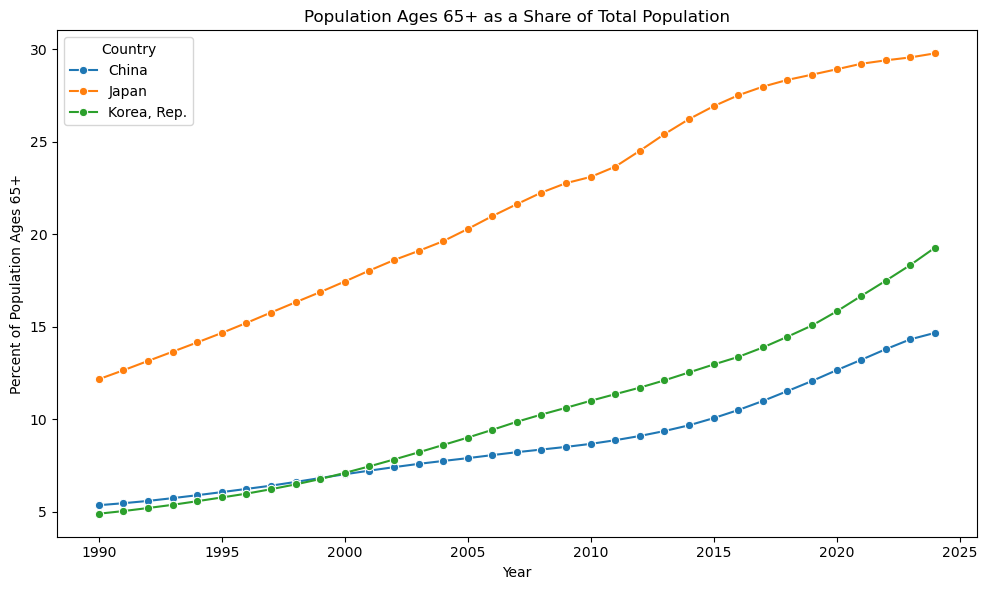

In [44]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=df_feat,
    x="year",
    y="pop65_pct",
    hue="country",
    marker="o"
)

plt.title("Population Ages 65+ as a Share of Total Population")
plt.xlabel("Year")
plt.ylabel("Percent of Population Ages 65+")
plt.legend(title="Country")
plt.tight_layout()
plt.show()

Japan remains the oldest country in the comparison, but China also shows a steady upward aging trend over time. For the target audience, this supports the view that elder-care demand in China is likely to remain a long-term structural issue.

### Chart 2. Nurses and Midwives per 1,000 People

This chart compares how the nursing workforce changed over time across the three countries.

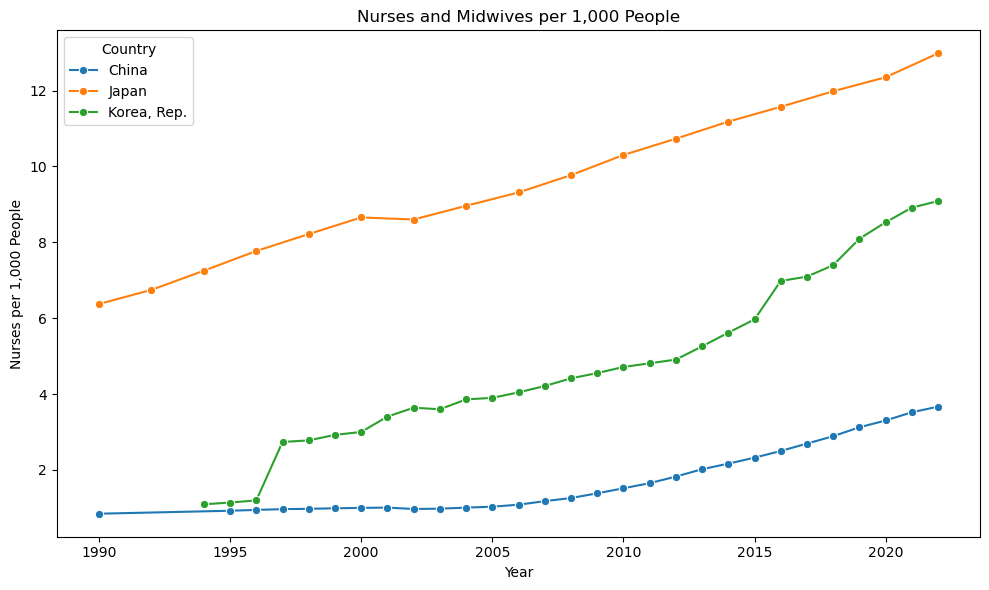

In [45]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=df_feat,
    x="year",
    y="nurses_per_1000",
    hue="country",
    marker="o"
)

plt.title("Nurses and Midwives per 1,000 People")
plt.xlabel("Year")
plt.ylabel("Nurses per 1,000 People")
plt.legend(title="Country")
plt.tight_layout()
plt.show()

Japan and South Korea show much higher nurse density than China for most of the sample, although this measure has some missing years. For a caregiver staffing business, this suggests that China may face relatively tighter care labor supply conditions.

### Chart 3. Estimated Older Adults per Nurse

This chart uses a simple proxy for labor pressure: the estimated number of adults ages 65+ per nurse.
Higher values suggest greater potential workforce pressure.

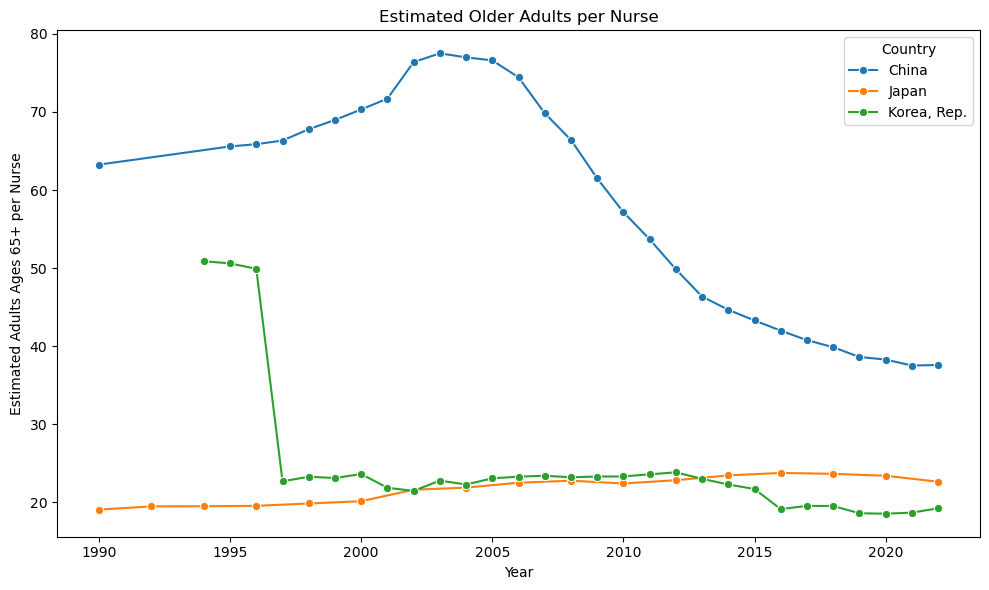

In [46]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=df_feat,
    x="year",
    y="elderly_per_nurse_est",
    hue="country",
    marker="o"
)

plt.title("Estimated Older Adults per Nurse")
plt.xlabel("Year")
plt.ylabel("Estimated Adults Ages 65+ per Nurse")
plt.legend(title="Country")
plt.tight_layout()
plt.show()

China shows a much higher estimated number of older adults per nurse than Japan or South Korea, which is consistent with a tighter elder-care labor market in this simple proxy. This is relevant to the target audience because labor tightness can create demand for worker training, matching, and placement services.

### Chart 4. China Elder-Care Beds per 1,000 Older Adults

This chart focuses on China only and shows how elder-care bed capacity changed relative to the size of the older population.

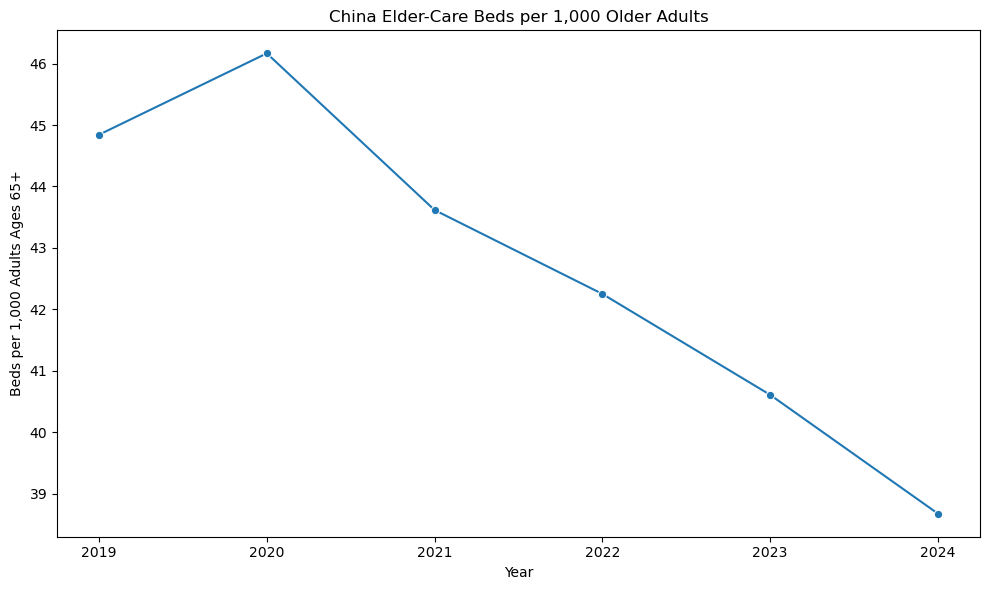

In [47]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=china_ops,
    x="year",
    y="beds_per_1000_65plus",
    marker="o"
)

plt.title("China Elder-Care Beds per 1,000 Older Adults")
plt.xlabel("Year")
plt.ylabel("Beds per 1,000 Adults Ages 65+")
plt.tight_layout()
plt.show()

Although total elder-care capacity remained large, beds per 1,000 older adults declined over this period as the older population continued to grow. For founders or investors, this suggests that rising demand may not be fully absorbed by existing capacity growth alone.

## 10. Modeling

The goal of the models is not to make a precise business forecast.  
Instead, the models help us test whether the observed relationships are broadly consistent with elder-care labor pressure.

### Model 1. Linear Regression

We first use a linear regression model to predict the estimated number of older adults per nurse.

In [48]:
# Keep only the columns needed for Model 1
model1_df = df_feat[[
    "elderly_per_nurse_est",
    "pop65_pct",
    "gdp_pc_usd",
    "year",
    "is_china",
    "aging_x_income"
]].dropna().copy()

print("Model 1 dataset shape:", model1_df.shape)
model1_df.head()

Model 1 dataset shape: (75, 6)


,elderly_per_nurse_est,pop65_pct,gdp_pc_usd,year,is_china,aging_x_income
0,63.256301,5.345157,318.503354,1990,1,1702.450562
5,65.580430,6.053074,612.680278,1995,1,3708.598858
6,65.873525,6.225048,713.337388,1996,1,4440.559514
7,66.332322,6.401069,786.743549,1997,1,5035.999765
8,67.792059,6.602946,835.095349,1998,1,5514.089905


In [49]:
# Define X and y
X = model1_df[["pop65_pct", "gdp_pc_usd", "year", "is_china", "aging_x_income"]]
y = model1_df["elderly_per_nurse_est"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Fit model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict
y_pred = lr_model.predict(X_test)

# Metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Linear Regression RMSE:", round(rmse, 2))
print("Linear Regression R-squared:", round(r2, 3))

Linear Regression RMSE: 8.97
Linear Regression R-squared: 0.826


In [50]:
coef_table = pd.DataFrame({
    "feature": X.columns,
    "coefficient": lr_model.coef_
}).round(4)

coef_table

,feature,coefficient
0,pop65_pct,-5.4122
1,gdp_pc_usd,-0.0015
2,year,-0.0749
3,is_china,28.8268
4,aging_x_income,0.0001


### Model 1 Notes

The linear regression model was estimated on 75 complete observations and produced an RMSE of **8.97** and an R-squared of **0.826**. This suggests that the model explains a substantial share of the variation in our elder-care labor pressure proxy, although it should still be treated as a simple screening model rather than a forecasting tool.

The results are relevant to the target audience because they suggest that aging, income, and country-specific differences are meaningfully related to labor pressure. In particular, the positive China indicator is consistent with the descriptive evidence that China may face relatively tighter elder-care labor conditions than the comparison countries.

The coefficient estimates should still be interpreted cautiously because the sample is small and several predictors are related to one another.

### Model 2. Logistic Regression

Next, we convert labor pressure into a binary outcome.  
Observations above the sample median of estimated older adults per nurse are labeled as high tension.
This gives us a simple classification model.

In [51]:
# Create binary target for Model 2
model2_df = model1_df.copy()

median_tension = model2_df["elderly_per_nurse_est"].median()
print("Median elderly_per_nurse_est:", round(median_tension, 2))

model2_df["high_tension_flag"] = (
    model2_df["elderly_per_nurse_est"] > median_tension
).astype(int)

print(model2_df["high_tension_flag"].value_counts())
model2_df.head()

Median elderly_per_nurse_est: 23.46
high_tension_flag
0    38
1    37
Name: count, dtype: int64


,elderly_per_nurse_est,pop65_pct,gdp_pc_usd,year,is_china,aging_x_income,high_tension_flag
0,63.256301,5.345157,318.503354,1990,1,1702.450562,1
5,65.580430,6.053074,612.680278,1995,1,3708.598858,1
6,65.873525,6.225048,713.337388,1996,1,4440.559514,1
7,66.332322,6.401069,786.743549,1997,1,5035.999765,1
8,67.792059,6.602946,835.095349,1998,1,5514.089905,1


In [52]:
# Define X and y
X2 = model2_df[["pop65_pct", "gdp_pc_usd", "year", "is_china", "aging_x_income"]]
y2 = model2_df["high_tension_flag"]

# Train-test split
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.3, random_state=42
)

# Fit logistic model
logit_model = LogisticRegression(max_iter=1000)
logit_model.fit(X2_train, y2_train)

# Predict
y2_pred = logit_model.predict(X2_test)

# Metrics
print("Logistic Regression Accuracy:", round(accuracy_score(y2_test, y2_pred), 3))
print("Logistic Regression Precision:", round(precision_score(y2_test, y2_pred), 3))
print("Logistic Regression Recall:", round(recall_score(y2_test, y2_pred), 3))

print("\nConfusion Matrix:")
print(confusion_matrix(y2_test, y2_pred))

Logistic Regression Accuracy: 0.87
Logistic Regression Precision: 1.0
Logistic Regression Recall: 0.769

Confusion Matrix:
[[10  0]
 [ 3 10]]


In [53]:
print(classification_report(y2_test, y2_pred))

              precision    recall  f1-score   support

           0       0.77      1.00      0.87        10
           1       1.00      0.77      0.87        13

    accuracy                           0.87        23
   macro avg       0.88      0.88      0.87        23
weighted avg       0.90      0.87      0.87        23



In [54]:
logit_coef_table = pd.DataFrame({
    "feature": X2.columns,
    "coefficient": logit_model.coef_[0]
}).round(4)

logit_coef_table

,feature,coefficient
0,pop65_pct,-0.1182
1,gdp_pc_usd,-0.0005
2,year,0.0030
3,is_china,0.9029
4,aging_x_income,0.0000


### Model 2 Notes

For the logistic regression, observations above the sample median of **23.46** older adults per nurse were labeled as high tension. The classes were fairly balanced, with 38 lower-tension observations and 37 higher-tension observations.

The model achieved an accuracy of **0.87**, precision of **1.00**, and recall of **0.769**. This means the model performed well overall and was especially strong when it predicted a high-tension observation, although it still missed some positive cases.

For the target audience, this supports the broader conclusion that relatively simple demographic and macro variables can already help distinguish higher-pressure labor environments from lower-pressure ones. That does not prove startup success, but it does support the idea that labor pressure is a real market condition worth investigating further.

## 11. Conclusion and Recommendations

### Key Findings

This analysis suggests three main findings that matter for founders or small investors evaluating a caregiver training and dispatch business in China.

First, the demand side is clearly growing. China’s 65+ population and 65+ population share both increased steadily over time, which supports the idea that elder-care demand will remain structurally important rather than temporary.

Second, labor supply pressure appears meaningful in our proxy measures. China has a lower nurse density than Japan and South Korea for most of the sample, and it also shows a much higher estimated number of older adults per nurse. For a target audience considering a caregiver training and dispatch business, this matters because a tighter labor market can create space for businesses that help recruit, train, and place care workers more efficiently.

Third, China’s elder-care system has expanded, but capacity growth may still lag the pace of population aging. In our China-only operations table, the older population continued to rise from 2019 to 2024, while beds per 1,000 older adults declined. For the target audience, this means the opportunity may not come only from building new facilities. It may also come from improving workforce availability and service delivery around existing elder-care demand.

Taken together, these results do not prove that a startup in caregiver training and dispatch will succeed. However, they do suggest that the business idea is relevant enough to justify deeper due diligence, especially in markets where aging demand is rising faster than care labor capacity.

### Limitations

This project has several limitations.

Most importantly, our labor-pressure measure is only a proxy. Nurses are not the same as trained elder-care workers, so the variable does not directly measure caregiver shortages in the specific business segment we care about.

In addition, the China operations dataset is small and simplified. It is useful for a high-level screening view, but it does not capture regional variation, service quality, utilization rates, wages, or vacancy pressure.

The modeling results should also be interpreted cautiously. The sample is limited, the features are simple, and some predictors are related to one another. The models are most useful as structured evidence that the observed patterns are consistent with labor pressure, not as precise forecasting tools.

For the target audience, this means the project should be interpreted as an early-stage market screening exercise rather than a full startup feasibility study.

### If We Had More Time

If we had more time, we would extend the project in ways that are even more useful for founders and investors.

First, we would add province-level or city-level data within China. That would help identify where caregiver demand is rising fastest and where labor shortages may be most severe.

Second, we would add more direct labor-market variables, such as caregiver wages, job postings, training program counts, elder-care worker certifications, or vacancy rates. These variables would better match the actual business model of caregiver training and dispatch.

Third, we would add market feasibility data, such as competitor presence, pricing, operating costs, and customer segments. That would move the project from broad market screening toward a more realistic startup opportunity assessment.

Overall, additional datasets would help answer not only whether the market is large, but also where the opportunity is strongest and whether a small startup could realistically compete.